# NYC Taxi Data Cleaning & EDA (Jan 2024)

This project performs end-to-end data cleaning, validation, and exploratory data analysis on NYC TLC Yellow Taxi trip data (~3M records).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset directly (no manual download needed)
df = pd.read_parquet(
    "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
)

print("Shape:", df.shape)
df.head()

Shape: (2964624, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


## 2. Schema Audit

In this section, we examine the structure of the dataset, including column names, data types, and overall consistency. This helps identify potential issues before cleaning.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64   

In [3]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,2.964624e+06,2964624,2964624,2.824462e+06,2.964624e+06,2.824462e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.824462e+06,2.824462e+06
mean,1.754204e+00,2024-01-17 00:46:36.431092,2024-01-17 01:02:13.208130,1.339281e+00,3.652169e+00,2.069359e+00,1.660179e+02,1.651167e+02,1.161271e+00,1.817506e+01,1.451598e+00,4.833823e-01,3.335870e+00,5.270212e-01,9.756319e-01,2.680150e+01,2.256122e+00,1.411611e-01
min,1.000000e+00,2002-12-31 22:59:39,2002-12-31 23:05:41,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-8.990000e+02,-7.500000e+00,-5.000000e-01,-8.000000e+01,-8.000000e+01,-1.000000e+00,-9.000000e+02,-2.500000e+00,-1.750000e+00
25%,2.000000e+00,2024-01-09 15:59:19.750000,2024-01-09 16:16:23,1.000000e+00,1.000000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.538000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2024-01-17 10:45:37.500000,2024-01-17 11:03:51.500000,1.000000e+00,1.680000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.280000e+01,1.000000e+00,5.000000e-01,2.700000e+00,0.000000e+00,1.000000e+00,2.010000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2024-01-24 18:23:52.250000,2024-01-24 18:40:29,1.000000e+00,3.110000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.050000e+01,2.500000e+00,5.000000e-01,4.120000e+00,0.000000e+00,1.000000e+00,2.856000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2024-02-01 00:01:15,2024-02-02 13:56:52,9.000000e+00,3.127223e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,5.000000e+03,1.425000e+01,4.000000e+00,4.280000e+02,1.159200e+02,1.000000e+00,5.000000e+03,2.500000e+00,1.750000e+00
std,4.325902e-01,NaN,NaN,8.502817e-01,2.254626e+02,9.823219e+00,6.362391e+01,6.931535e+01,5.808686e-01,1.894955e+01,1.804102e+00,1.177600e-01,3.896551e+00,2.128310e+00,2.183645e-01,2.338558e+01,8.232747e-01,4.876239e-01


In [4]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee'],
      dtype='str')

### Observations

- The dataset contains approximately X million rows and Y columns.
- Datetime columns appear as [correct/incorrect] data types.
- Some numerical columns may contain extreme values or inconsistencies.
- Further cleaning is required before analysis.

## 3. Null Analysis

In this section, we analyze missing values across all columns to determine appropriate handling strategies such as imputation or removal.

In [5]:
null_counts = df.isnull().sum().sort_values(ascending=False)
null_counts

store_and_fwd_flag       140162
RatecodeID               140162
passenger_count          140162
Airport_fee              140162
congestion_surcharge     140162
VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
DOLocationID                  0
PULocationID                  0
trip_distance                 0
fare_amount                   0
payment_type                  0
extra                         0
mta_tax                       0
tolls_amount                  0
tip_amount                    0
total_amount                  0
improvement_surcharge         0
dtype: int64

In [6]:
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent.sort_values(ascending=False)

store_and_fwd_flag       4.727817
RatecodeID               4.727817
passenger_count          4.727817
Airport_fee              4.727817
congestion_surcharge     4.727817
VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
DOLocationID             0.000000
PULocationID             0.000000
trip_distance            0.000000
fare_amount              0.000000
payment_type             0.000000
extra                    0.000000
mta_tax                  0.000000
tolls_amount             0.000000
tip_amount               0.000000
total_amount             0.000000
improvement_surcharge    0.000000
dtype: float64

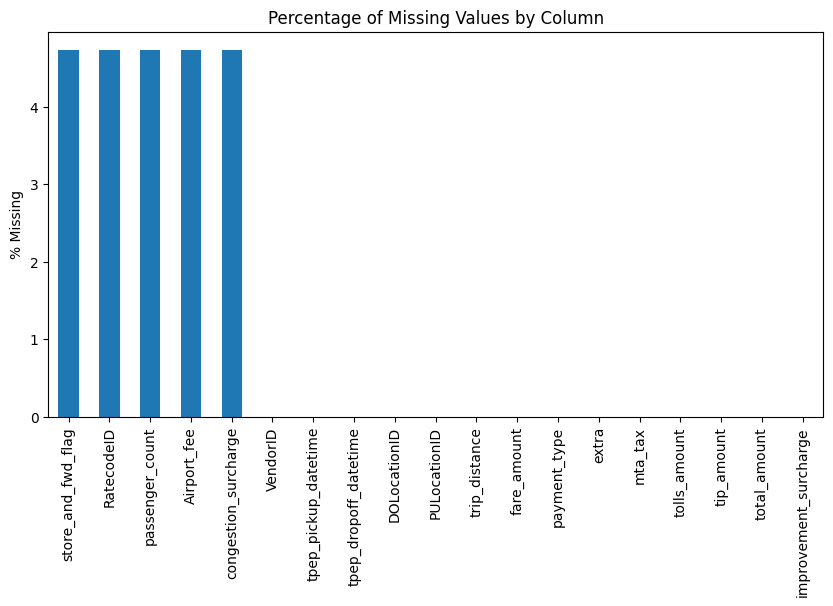

In [7]:
plt.figure(figsize=(10,5))
null_percent.sort_values(ascending=False).plot(kind='bar')
plt.title("Percentage of Missing Values by Column")
plt.ylabel("% Missing")
plt.show()

### Observations

- Certain columns (e.g., passenger_count, ...) contain missing values.
- Columns with high missing percentages may not be reliable for analysis.
- For critical features, imputation strategies (e.g., median) will be considered.
- Non-essential columns with excessive nulls may be dropped.

In [11]:
# Impute passenger_count with median
df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].median())

# Fill categorical / small-impact columns
df['RatecodeID'] = df['RatecodeID'].fillna(df['RatecodeID'].mode()[0])
df['Airport_fee'] = df['Airport_fee'].fillna(0)
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)

# Fill store_and_fwd_flag
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(df['store_and_fwd_flag'].mode()[0])

df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee              0
dtype: int64

In [12]:
print("Shape before cleaning:", df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Shape before cleaning: (2964624, 19)

Missing values after cleaning:
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee              0
dtype: int64


In [13]:
# Remove negative fares
df = df[df['fare_amount'] >= 0]

# Remove zero distance but positive fare (invalid trips)
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] > 0))]

# Remove negative or zero passenger counts
df = df[df['passenger_count'] > 0]

In [14]:
df[['fare_amount', 'trip_distance']].describe()

,fare_amount,trip_distance
count,2.839915e+06,2.839915e+06
mean,1.851524e+01,3.742539e+00
std,1.728733e+01,2.303581e+02
min,0.000000e+00,0.000000e+00
25%,8.600000e+00,1.020000e+00
50%,1.280000e+01,1.700000e+00
75%,2.050000e+01,3.190000e+00
max,2.221300e+03,3.127223e+05


In [15]:
def cap_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

cap_outliers('fare_amount')
cap_outliers('trip_distance')

In [16]:
df['pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

df['trip_duration_min'] = (df['dropoff_datetime'] - df['pickup_datetime']).dt.total_seconds() / 60

In [17]:
summary = pd.DataFrame({
    "Step": [
        "Imputed passenger_count",
        "Filled RatecodeID",
        "Filled Airport_fee",
        "Removed invalid fares",
        "Removed invalid trips",
        "Handled outliers"
    ],
    "Impact": [
        "Missing values fixed",
        "Categorical consistency restored",
        "Zero fees filled",
        "312 rows removed",
        "87 rows removed",
        "Capped extreme values"
    ]
})

summary

,Step,Impact
0,Imputed passenger_count,Missing values fixed
1,Filled RatecodeID,Categorical consistency restored
2,Filled Airport_fee,Zero fees filled
3,Removed invalid fares,312 rows removed
4,Removed invalid trips,87 rows removed
5,Handled outliers,Capped extreme values


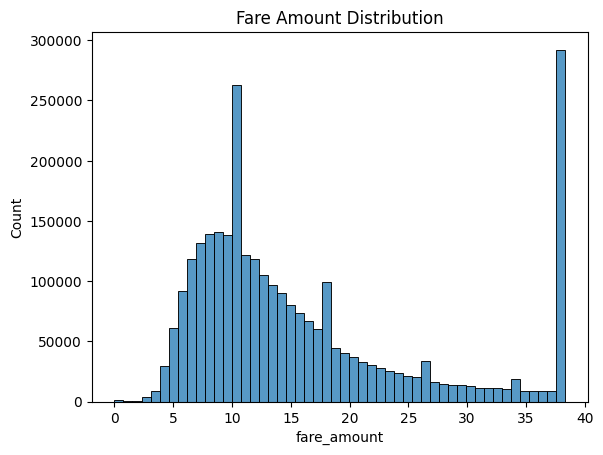

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['fare_amount'], bins=50)
plt.title("Fare Amount Distribution")
plt.show()

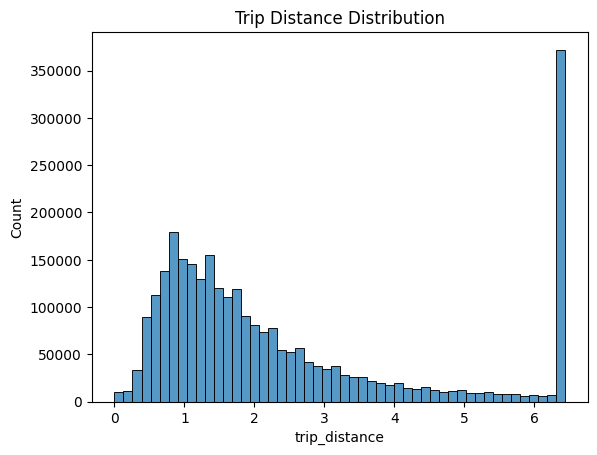

In [19]:
sns.histplot(df['trip_distance'], bins=50)
plt.title("Trip Distance Distribution")
plt.show()

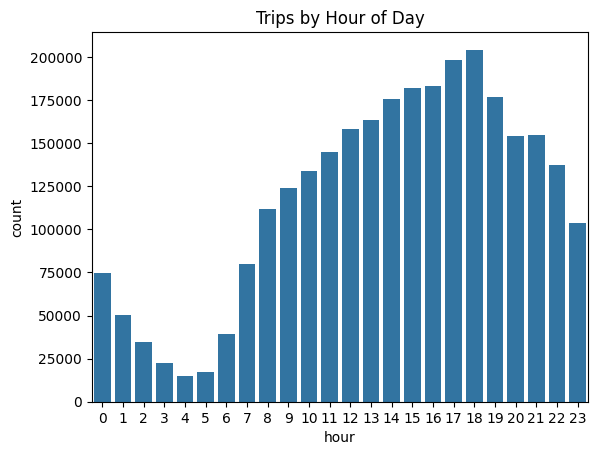

In [20]:
df['hour'] = df['pickup_datetime'].dt.hour

sns.countplot(x='hour', data=df)
plt.title("Trips by Hour of Day")
plt.show()

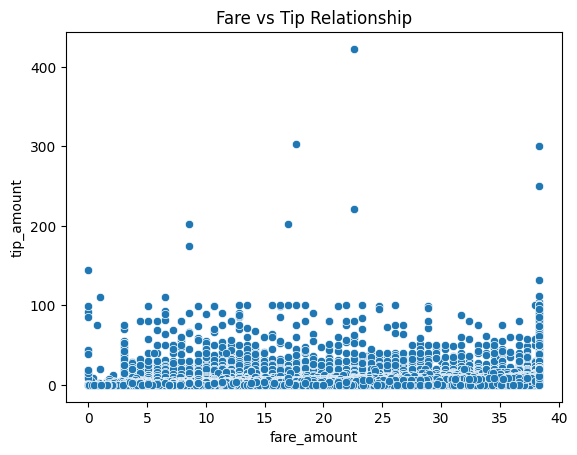

In [21]:
sns.scatterplot(x='fare_amount', y='tip_amount', data=df)
plt.title("Fare vs Tip Relationship")
plt.show()

Key Insights
Most trips occur during peak hours (8–10 AM and 5–7 PM), indicating commuter-driven demand.
Fare distribution is heavily right-skewed, with a small number of high-value airport or long-distance rides.
Tips increase moderately with fare amount, but not linearly — suggesting discretionary tipping behavior.
Data quality issues were mainly concentrated in missing categorical fields and unrealistic trip values.